In [46]:
# Install Libraries
!pip install -q scikit-learn pandas matplotlib seaborn

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

In [48]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [49]:
df.shape

(55551, 31)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55551 entries, 0 to 55550
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    55551 non-null  int64  
 1   V1      55551 non-null  float64
 2   V2      55551 non-null  float64
 3   V3      55551 non-null  float64
 4   V4      55551 non-null  float64
 5   V5      55551 non-null  float64
 6   V6      55551 non-null  float64
 7   V7      55551 non-null  float64
 8   V8      55551 non-null  float64
 9   V9      55551 non-null  float64
 10  V10     55551 non-null  float64
 11  V11     55551 non-null  float64
 12  V12     55551 non-null  float64
 13  V13     55551 non-null  float64
 14  V14     55551 non-null  float64
 15  V15     55550 non-null  float64
 16  V16     55550 non-null  float64
 17  V17     55550 non-null  float64
 18  V18     55550 non-null  float64
 19  V19     55550 non-null  float64
 20  V20     55550 non-null  float64
 21  V21     55550 non-null  float64
 22

In [51]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [52]:
df["Class"].value_counts()

,count
Class,
0.0,55394
1.0,156


In [53]:
fraud = df[df.Class==1]
normal = df[df.Class==0]

print(fraud.shape)
print(normal.shape)

(156, 31)
(55394, 31)


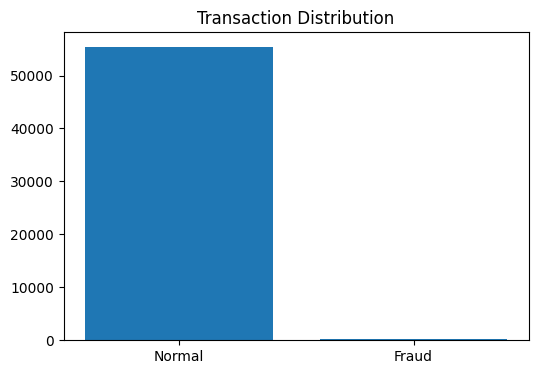

In [54]:
fraud_count = len(df[df.Class==1])
normal_count = len(df[df.Class==0])

plt.figure(figsize=(6,4))
plt.bar(["Normal","Fraud"],[normal_count,fraud_count])
plt.title("Transaction Distribution")
plt.show()

In [55]:
X = df.drop("Class",axis=1)

y = df["Class"]

In [56]:
scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X["Amount"].values.reshape(-1,1))
X["Time"] = scaler.fit_transform(X["Time"].values.reshape(-1,1))

In [57]:
X = X.dropna()
y = y.dropna()

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [59]:
prediction=model.predict(X_test)

In [60]:
accuracy=accuracy_score(y_test,prediction)

print("Accuracy :",accuracy)

Accuracy : 0.998019801980198


In [61]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     11079
         1.0       0.65      0.65      0.65        31

    accuracy                           1.00     11110
   macro avg       0.82      0.82      0.82     11110
weighted avg       1.00      1.00      1.00     11110



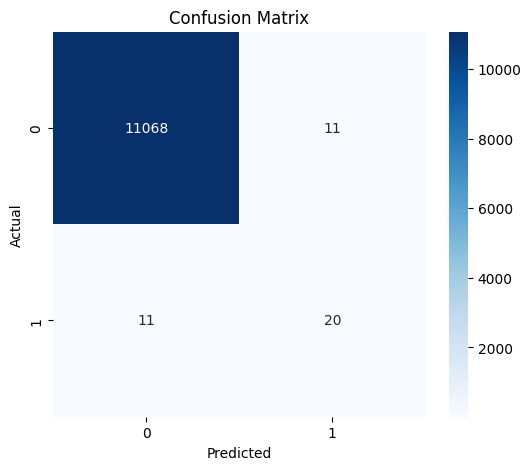

In [62]:
cm=confusion_matrix(y_test,prediction)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [63]:
roc=roc_auc_score(y_test,prediction)

print("ROC AUC Score :",roc)

ROC AUC Score : 0.8220842104650179


In [64]:
sample=X_test.iloc[0:1]

prediction=model.predict(sample)

print(prediction)

[0.]


In [65]:
import pickle

pickle.dump(model,open("credit_card_model.pkl","wb"))